# **Setup**

In [ ]:
!pip -q install torch torchvision torchaudio scikit-learn pandas matplotlib yfinance

In [25]:
# Core
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, math, time, random

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Sklearn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

# Reproducibility
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


# **Getting Data**

In [ ]:
# # Mount Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

# Define your file path (update if your folder name is different)
zip_path = '/content/drive/MyDrive/ColabNotebooks/Dataset/archive.zip'
extract_path = '/content/drive/MyDrive/ColabNotebooks/Dataset/stock_data'

# Unzip the file
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("File unzipped successfully to:", extract_path)

File unzipped successfully to: /content/drive/MyDrive/ColabNotebooks/Dataset/stock_data


In [ ]:
# Load one ticker (baseline)
df = pd.read_csv("/content/drive/MyDrive/ColabNotebooks/Dataset/stock_data/stocks/AAPL.csv", parse_dates=["Date"]).sort_values("Date")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9909 entries, 0 to 9908
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       9909 non-null   datetime64[ns]
 1   Open       9909 non-null   float64       
 2   High       9909 non-null   float64       
 3   Low        9909 non-null   float64       
 4   Close      9909 non-null   float64       
 5   Adj Close  9909 non-null   float64       
 6   Volume     9909 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 542.0 KB


# **Preparing Dataset for Training**

In [ ]:
# Build supervised target: next-day close
df["target_next_close"] = df["Close"].shift(-1)
df = df.dropna().reset_index(drop=True)

# ====== 3) Choose features ======
# Start simple: only close; for stronger model, use OHLCV
# features = ["close"]                      # simple
features = ["Open","High","Low","Close","Volume"]  # stronger
target = "target_next_close"

data = df[features + [target]].copy()

# ====== 4) Train/val/test split by time ======
n = len(data)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)
train_df  = data.iloc[:train_end]
val_df    = data.iloc[train_end:val_end]
test_df   = data.iloc[val_end:]

# ====== 5) Scale features (fit on TRAIN only) ======
x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

x_scaler.fit(train_df[features])
y_scaler.fit(train_df[[target]])

def scale_xy(df):
    X = x_scaler.transform(df[features])
    y = y_scaler.transform(df[[target]])
    return X, y

X_train, y_train = scale_xy(train_df)
X_val,   y_val   = scale_xy(val_df)
X_test,  y_test  = scale_xy(test_df)

# ====== 6) Build sequences of length window_size ======
window_size = 60

def make_sequences(X, y, win):
    Xs, ys = [], []
    for i in range(len(X) - win):
        Xs.append(X[i:i+win])
        ys.append(y[i+win])  # predict next step
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)

X_train_seq, y_train_seq = make_sequences(X_train, y_train, window_size)
X_val_seq,   y_val_seq   = make_sequences(X_val,   y_val,   window_size)
X_test_seq,  y_test_seq  = make_sequences(X_test,  y_test,  window_size)

print("Shapes:",
      X_train_seq.shape, y_train_seq.shape,
      X_val_seq.shape,   y_val_seq.shape,
      X_test_seq.shape,  y_test_seq.shape)

# ====== 7) PyTorch Dataset/DataLoader ======
class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)   # (N, T, F)
        self.y = torch.from_numpy(y)   # (N, 1)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, i):
        return self.X[i], self.y[i]

batch_size = 64
train_loader = DataLoader(SeqDataset(X_train_seq, y_train_seq), batch_size=batch_size, shuffle=True, drop_last=True)
val_loader   = DataLoader(SeqDataset(X_val_seq,   y_val_seq),   batch_size=batch_size, shuffle=False, drop_last=False)
test_loader  = DataLoader(SeqDataset(X_test_seq,  y_test_seq),  batch_size=batch_size, shuffle=False, drop_last=False)

Shapes: (6875, 60, 5) (6875, 1) (1426, 60, 5) (1426, 1) (1427, 60, 5) (1427, 1)


# **Defining the LSTM Model**

In [ ]:
# ====== 8) LSTM model ======
class LSTMRegressor(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size,
                            hidden_size=hidden_size,
                            num_layers=num_layers,
                            batch_first=True,
                            dropout=dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: (B, T, F)
        out, _ = self.lstm(x)        # (B, T, H)
        out = out[:, -1, :]          # last time step (B, H)
        out = self.fc(out)           # (B, 1)
        return out

model = LSTMRegressor(input_size=len(features)).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Schedulers / helpers
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)
early_patience = 8
best_val = np.inf
patience = 0
clip_norm = 1.0

# **Training the Model**

In [ ]:
# ====== 9) Training loop ======
epochs = 40
train_losses, val_losses = [], []

for epoch in range(1, epochs+1):
    model.train()
    epoch_train = 0.0
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), clip_norm)
        optimizer.step()
        epoch_train += loss.item() * xb.size(0)

    epoch_train /= len(train_loader.dataset)
    train_losses.append(epoch_train)

    # validate
    model.eval()
    epoch_val = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            loss = criterion(preds, yb)
            epoch_val += loss.item() * xb.size(0)
    epoch_val /= len(val_loader.dataset)
    val_losses.append(epoch_val)

    scheduler.step(epoch_val)

    if epoch_val < best_val:
        best_val = epoch_val
        patience = 0
        torch.save(model.state_dict(), "best_lstm.pth")
    else:
        patience += 1

    print(f"Epoch {epoch:02d}/{epochs} | train MSE: {epoch_train:.6f} | val MSE: {epoch_val:.6f} | lr: {optimizer.param_groups[0]['lr']:.1e}")

    if patience >= early_patience:
        print("Early stopping.")
        break

Epoch 01/40 | train MSE: 0.004719 | val MSE: 0.474361 | lr: 1.0e-03
Epoch 02/40 | train MSE: 0.000213 | val MSE: 0.526027 | lr: 1.0e-03
Epoch 03/40 | train MSE: 0.000192 | val MSE: 0.526876 | lr: 1.0e-03
Epoch 04/40 | train MSE: 0.000207 | val MSE: 0.496882 | lr: 1.0e-03
Epoch 05/40 | train MSE: 0.000168 | val MSE: 0.432502 | lr: 1.0e-03
Epoch 06/40 | train MSE: 0.000185 | val MSE: 0.407096 | lr: 1.0e-03
Epoch 07/40 | train MSE: 0.000164 | val MSE: 0.338840 | lr: 1.0e-03
Epoch 08/40 | train MSE: 0.000164 | val MSE: 0.314252 | lr: 1.0e-03
Epoch 09/40 | train MSE: 0.000162 | val MSE: 0.320502 | lr: 1.0e-03
Epoch 10/40 | train MSE: 0.000186 | val MSE: 0.297882 | lr: 1.0e-03
Epoch 11/40 | train MSE: 0.000146 | val MSE: 0.379398 | lr: 1.0e-03
Epoch 12/40 | train MSE: 0.000144 | val MSE: 0.434613 | lr: 1.0e-03
Epoch 13/40 | train MSE: 0.000131 | val MSE: 0.337250 | lr: 1.0e-03
Epoch 14/40 | train MSE: 0.000141 | val MSE: 0.300170 | lr: 5.0e-04
Epoch 15/40 | train MSE: 0.000142 | val MSE: 0.3

# **Evaluating the Model**

Test R²: -2.381 | Test MAE: $84.66


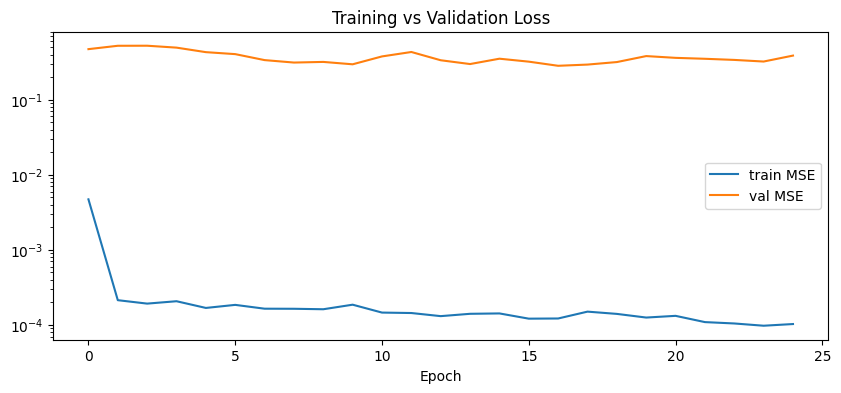

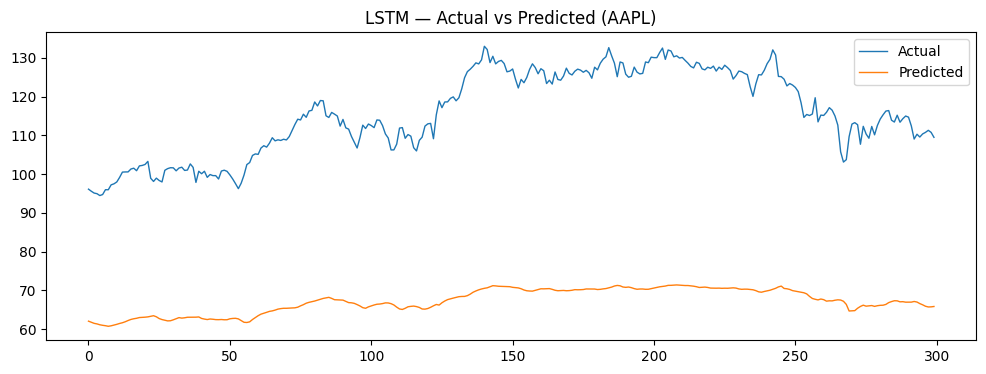

In [28]:
# ====== 10) Load best and evaluate on TEST (R² + MAE) ======
model.load_state_dict(torch.load("best_lstm.pth"))
model.eval()

def collect(loader):
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            pred = model(xb).cpu().numpy()
            preds.append(pred)
            trues.append(yb.numpy())
    preds = np.vstack(preds)
    trues = np.vstack(trues)
    # invert scaling
    preds_inv = y_scaler.inverse_transform(preds)
    trues_inv = y_scaler.inverse_transform(trues)
    return trues_inv.squeeze(), preds_inv.squeeze()

y_true_test, y_pred_test = collect(test_loader)

r2  = r2_score(y_true_test, y_pred_test)
mae = mean_absolute_error(y_true_test, y_pred_test)
print(f"Test R²: {r2:.3f} | Test MAE: ${mae:,.2f}")

# ====== 11) Curves + visual ======
plt.figure(figsize=(10,4))
plt.plot(train_losses, label="train MSE")
plt.plot(val_losses, label="val MSE")
plt.yscale("log")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.legend(); plt.show()

# Extract ticker from filename (had complicaion trying to get the ticker...)
import os
file_path = "/content/drive/MyDrive/ColabNotebooks/Dataset/stock_data/stocks/AAPL.csv"
ticker = os.path.splitext(os.path.basename(file_path))[0]

plt.figure(figsize=(12,4))
plt.plot(y_true_test[:300], label="Actual", linewidth=1)
plt.plot(y_pred_test[:300], label="Predicted", linewidth=1)
plt.title(f"LSTM — Actual vs Predicted ({ticker})")
plt.legend(); plt.show()